<a target="_blank" href="https://colab.research.google.com/github/ZHAW-ZAV/TSO-FS25/blob/main/06_supervised_ml/rway_prediction_A321.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Exercise: Predicting Runway Choice for A321 Departures at Zurich Airport

**Objective:**  
Your task is to design and build a machine learning (ML) model that predicts whether an Airbus A321 departing from Zurich Airport (ZRH) will take off from Runway 28 or Runway 16. The prediction should be made in advance, based on relevant data features you identify.

**Background:**  
Zurich Airport has multiple runways, but the choice of runway for departing flights like the A321—a medium-sized aircraft—can significantly impact airport operations:  
- **Runway 28**: Shorter taxiing distance, allowing quicker departures. It operates independently of other runways, making it efficient for scheduling.  
- **Runway 16**: Longer runway, typically reserved for heavier aircraft due to its length. However, it cannot operate independently of Runway 14 (used for landings). When an aircraft is landing on Runway 14, departures on Runway 16 must wait, potentially causing delays and reducing airport capacity.  

The A321 is a versatile aircraft: when lightly loaded, it can use Runway 28, but when heavily loaded (e.g., with more passengers, cargo, or fuel), it may require Runway 16 for a safer takeoff. Currently, the runway request is made by the airline or pilot closer to departure, which limits the airport’s ability to optimize planning.

**Why It Matters:**  
Predicting the runway choice in advance offers significant value for airport operations:  
- **Improved Efficiency**: Knowing early whether an A321 will use Runway 28 or 16 helps optimize taxiing routes and departure sequencing, reducing ground delays.  
- **Capacity Management**: Avoiding unnecessary use of Runway 16 minimizes conflicts with landings on Runway 14, preserving overall airport throughput.  
- **Resource Planning**: Accurate predictions allow better allocation of gates, ground crew, and equipment based on expected taxiing times and runway usage.  

**Your Task:**  
1. Identify potential data inputs (features) that could influence the A321’s runway
2. Build a simple ML model
3. Evaluate the model

# Dataset loading

The dataset is a csv file stored on a google drive.
You will load it into a pandas dataframe.



In [67]:
import pandas as pd
file_id = "1bKB2Fkt-iRQTS06zZ-YKkPUsQPuuyj_T"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
df = pd.read_csv(url)
df.head()

,icao24,callsign,timestamp,runway,dest_max,dist_lszh,typecode,temperature,pressure,tailwind_16,tailwind_28,wind_gust
0,4b168f,SWR185N,2018-01-01 08:59:28+00:00,28,LGAV,1989.017568,A321,5.0,1015.0,3.500000,3.500000,NaN
1,461fa4,FIN8PY,2018-01-01 10:04:38+00:00,28,EFHK,2278.074743,A321,6.0,1015.0,4.446262,8.356239,NaN
2,4baa8e,THY9SC,2018-01-01 10:20:24+00:00,28,LTFM,2337.168213,A321,6.0,1014.0,5.814342,10.927389,NaN
3,4b1696,SWR43B,2018-01-01 11:27:53+00:00,16,EGLL,1096.085110,A321,7.0,1013.0,2.257426,9.958578,NaN
4,4b1698,SWR204K,2018-01-01 11:29:38+00:00,16,LPPR,2035.584651,A321,7.0,1013.0,2.257426,9.958578,NaN


# Exploratory Data Analysis

In [68]:
df['runway'].value_counts()

runway
28    21110
16     7135
Name: count, dtype: int64

In [69]:
df['from_16'] = (df['runway']==16).astype(int)
df.from_16.value_counts()

from_16
0    21110
1     7135
Name: count, dtype: int64

## Correlation plot for numerical variables

In [70]:
import plotly.express as px
# plot correlation matrix
corr_matrix = df[['dist_lszh', 'temperature', 'pressure', 'tailwind_16', 'tailwind_28', 'wind_gust', 'from_16']].corr()
fig = px.imshow(
    corr_matrix,
    text_auto=True,  # display correlation values on the heatmap
    aspect="auto",
    color_continuous_scale="RdBu",
    range_color=[-1,1],
    
    title="Correlation Heatmap of Aircraft Data",
    height=600,
    width=600
)
fig.show()

## Categorical variables

Let's have a look at the top 20 callsigns:

In [71]:
top20cs = df.callsign.value_counts().head(20).index
subset = df.query("callsign in @top20cs")
subset.groupby('callsign').agg({'from_16':['count', 'mean'], 'dest_max':'first'}).sort_values(('from_16', 'mean'), ascending=False)

from_16           dest_max
           count      mean    first
callsign                           
SWR204K      314  0.853503     LPPR
SWR204M      390  0.810256     LPPT
SWR219J      513  0.771930     LEMG
SWR42H       413  0.738499     EIDW
SWR106Y      416  0.668269     LGAV
SWR185N      602  0.616279     LGAV
SWR248M      472  0.569915     LEMG
SWR1956      305  0.445902     LEBL
SWR131C      638  0.423197     LEBL
SWR218L      417  0.364508     LEPA
SWR129L      349  0.361032     EKCH
SWR125B      301  0.318937     EKCH
SWR734       405  0.224691     EHAM
SWR198F      600  0.138333     LEBL
SWR31J       413  0.101695     EGLL
TAP927M      479  0.060543     LPPR
FIN8PY       473  0.006342     EFHK
FIN6KP       536  0.005597     EFHK
AEE5ZH       437  0.002288     LGAV
SWR83GR      535  0.001869     LSGG

Let's have a look at the top 20 destinations:

In [72]:
top20dest = df.dest_max.value_counts().head(20).index
subset = df.query("dest_max in @top20dest")
subset.groupby('dest_max').agg({'from_16':['count', 'mean']}).sort_values(('from_16', 'mean'), ascending=False)

from_16          
           count      mean
dest_max                  
EIDW         461  0.704989
LEMG        1324  0.642749
ESSA         536  0.567164
LPPR         474  0.527426
LGAV        1341  0.501119
LPPT        1849  0.447810
LQSA         464  0.346983
LEBL        2417  0.304510
LEPA        1284  0.271028
EKCH        1191  0.247691
EHAM         894  0.168904
EDDH         959  0.163712
LIRF         717  0.132497
EDDB         830  0.112048
LOWW         980  0.096939
EGLL        1646  0.070474
LTFM        2512  0.044984
EDDF         744  0.025538
LSGG        1211  0.020644
EFHK        1011  0.005935

# Preparing the dataset

In [73]:
df

,icao24,callsign,timestamp,runway,dest_max,dist_lszh,typecode,temperature,pressure,tailwind_16,tailwind_28,wind_gust,from_16
0,4b168f,SWR185N,2018-01-01 08:59:28+00:00,28,LGAV,1989.017568,A321,5.0,1015.0,3.500000,3.500000,NaN,0
1,461fa4,FIN8PY,2018-01-01 10:04:38+00:00,28,EFHK,2278.074743,A321,6.0,1015.0,4.446262,8.356239,NaN,0
2,4baa8e,THY9SC,2018-01-01 10:20:24+00:00,28,LTFM,2337.168213,A321,6.0,1014.0,5.814342,10.927389,NaN,0
3,4b1696,SWR43B,2018-01-01 11:27:53+00:00,16,EGLL,1096.085110,A321,7.0,1013.0,2.257426,9.958578,NaN,1
4,4b1698,SWR204K,2018-01-01 11:29:38+00:00,16,LPPR,2035.584651,A321,7.0,1013.0,2.257426,9.958578,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28240,4b194b,SWR211G,2023-02-09 17:15:51+00:00,28,EBBR,590.609032,A21N,3.0,1033.0,NaN,NaN,NaN,0
28241,49514a,TAP927Z,2023-02-09 17:19:31+00:00,28,LPPT,2188.615183,A21N,3.0,1033.0,NaN,NaN,NaN,0
28242,461fa4,FIN5XB,2023-02-09 18:18:21+00:00,28,EFHK,2278.074743,A321,0.0,1033.0,1.000000,-2.000000,NaN,0
28243,4bb26f,THY8GU,2023-02-09 18:28:57+00:00,28,LTFM,2337.168213,A21N,-1.0,1034.0,1.532089,-1.879385,NaN,0


Using the scikit learn library, we will create a training and testing dataset:

In [74]:
df['timestamp'] = pd.to_datetime(df.timestamp)
df['hour'] = df.timestamp.dt.hour
df['hour']
df['dow'] = df.timestamp.dt.dayofweek
df['weekend'] = df.dow.isin([5,6])
df['weekend']

df['airline'] = df.callsign.str[:3]
df['airline']


0        SWR
1        FIN
2        THY
3        SWR
4        SWR
        ... 
28240    SWR
28241    TAP
28242    FIN
28243    THY
28244    EZY
Name: airline, Length: 28245, dtype: str

In [75]:
from sklearn.model_selection import train_test_split
# Convert categorical features to dummy variables
categorical_features = ['callsign', 'dest_max', 'airline']
df_features = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Define features including numeric ones and all dummy columns from 'callsign' and 'dest_max'
features = [
    "temperature",
    # "pressure",
    "tailwind_28",
    "tailwind_16",
    "dist_lszh",
    "hour",
    "weekend"
] + [c for c in df_features.columns if c.startswith('airline_')]

# Define features and target variable
X = df_features[features]
y = df_features["from_16"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y,
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((19771, 42), (19771,), (8474, 42), (8474,))

In [76]:
X_train

,temperature,tailwind_28,tailwind_16,dist_lszh,hour,weekend,airline_AEA,airline_AEE,airline_AFL,airline_AFR,...,airline_OMD,airline_PGT,airline_RJA,airline_SAS,airline_SWR,airline_TAP,airline_THY,airline_TUI,airline_VLG,airline_WZZ
17995,15.0,NaN,NaN,696.018987,5,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
11241,21.0,-5.510911e-16,-2.598076,2188.615183,16,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
7126,3.0,NaN,NaN,991.109383,6,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
19622,21.0,-1.389185e+00,-6.128356,1132.356537,10,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
21282,1.0,1.928363e+00,-2.954423,1087.198303,7,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7393,4.0,-2.052121e+00,-3.856726,282.835100,9,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11500,29.0,NaN,NaN,894.765590,16,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1073,-1.0,NaN,NaN,742.822680,6,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
24336,17.0,-3.856726e+00,5.908847,2188.615183,12,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


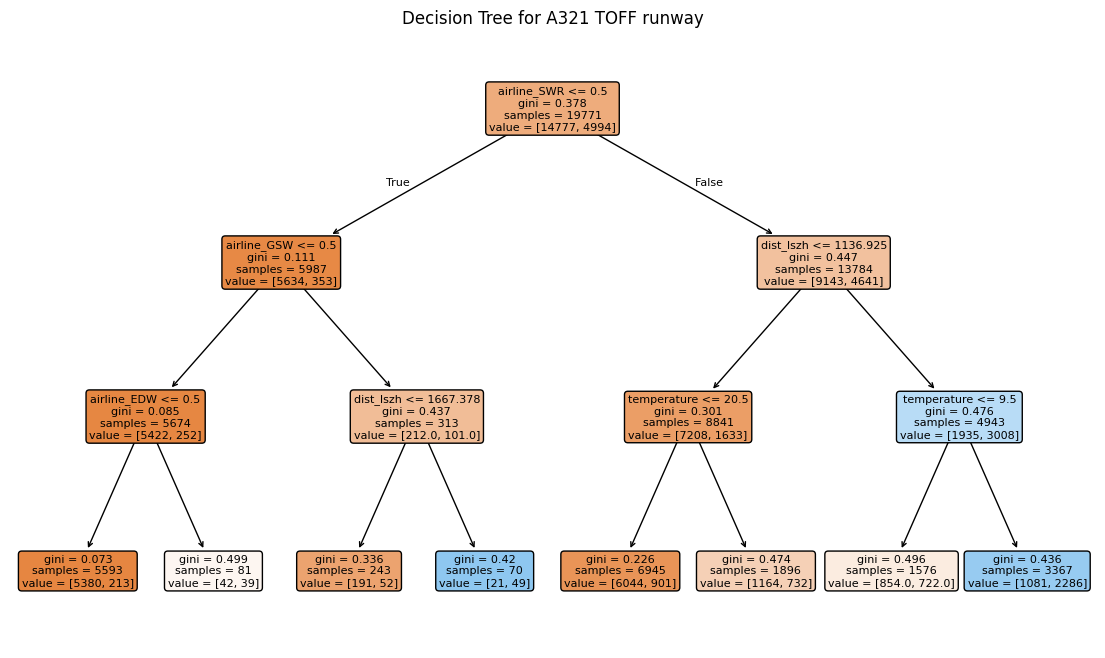

[[5808  525]
 [ 813 1328]]


In [77]:
from matplotlib import pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
import numpy as np

tree_reg = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_reg.fit(X_train, y_train)


# Visualize the decision tree
plt.figure(figsize=(14, 8))
plot_tree(tree_reg, feature_names=X.columns, filled=True, rounded=True, fontsize=8)
plt.title("Decision Tree for A321 TOFF runway")
plt.show()
# print the confustion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)


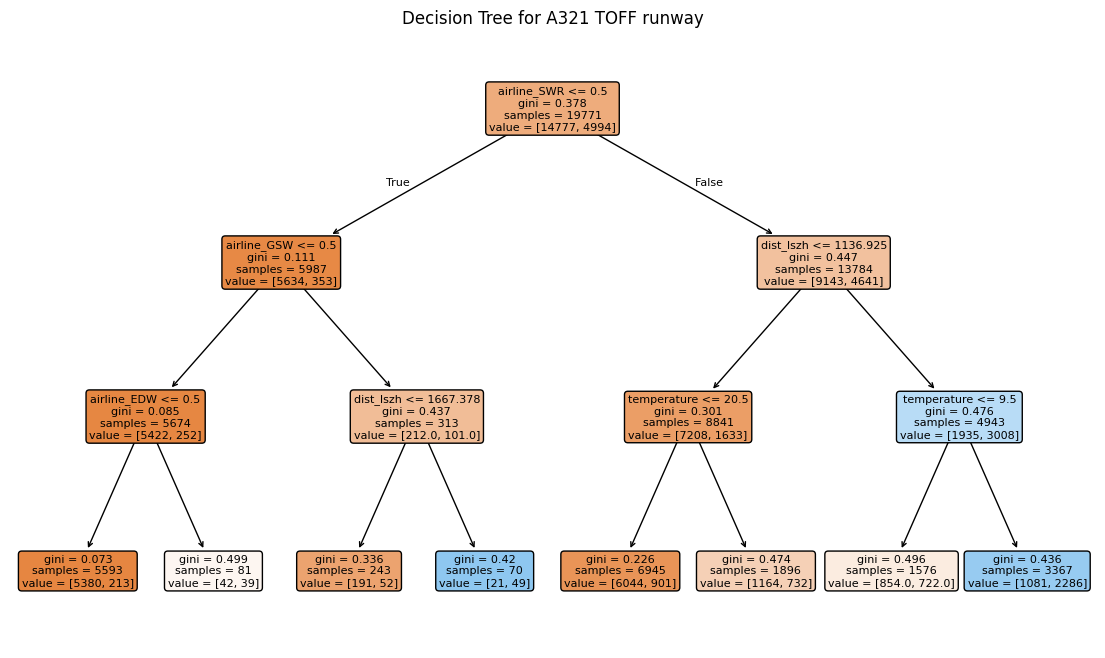

In [78]:
plt.figure(figsize=(14, 8))
plot_tree(tree_reg, feature_names=X.columns, filled=True, rounded=True, fontsize=8)
plt.title("Decision Tree for A321 TOFF runway")
plt.show()


# Model Evaluation

In [79]:
from sklearn.metrics import confusion_matrix, classification_report

# Predict on the test set
y_pred = tree_reg.predict(X_test)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Optionally, print a detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[5872  461]
 [1185  956]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      6333
           1       0.67      0.45      0.54      2141

    accuracy                           0.81      8474
   macro avg       0.75      0.69      0.71      8474
weighted avg       0.79      0.81      0.79      8474



In [85]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel().tolist()
tn, fp, fn, tp 

(5872, 461, 1185, 956)

# Implement Recall, Precision and F1 Score by yourself

In [92]:
# true positives
tp = ((y_test == 1) & (y_pred == 1)).sum()
# false positives
fp = ((y_test == 0) & (y_pred == 1)).sum()
# false negatives
fn = ((y_test == 1) & (y_pred == 0)).sum()
# true negatives
tn = ((y_test == 0) & (y_pred == 0)).sum()
# recall
recall = tp / (tp + fn)
# precision
precision = tp / (tp + fp)
# f1 score
f1 = 2 * (precision * recall) / (precision + recall)
print(f"TP={tp}, FP={fp}, FN={fn}, TN={tn}")
print(f"Recall: {recall:.2f}, Precision: {precision:.2f}, F1 Score: {f1:.2f}")


TP=956, FP=461, FN=1185, TN=5872
Recall: 0.45, Precision: 0.67, F1 Score: 0.54


In [98]:
y_pred = tree_reg.predict(X_test)
y_proba = tree_reg.predict_proba(X_test)[:, 1]  # probability of 'from_16' = 1
y_proba

array([0.03808332, 0.12973362, 0.38607595, ..., 0.12973362, 0.12973362,
       0.45812183], shape=(8474,))

In [ ]:
y_pred = tree_reg.predict(X_test)
y_proba = tree_reg.predict_proba(X_test)[:, 1]  # probability of 'from_16' = 1

# probas_false_positives = y_proba[(y_test == 0) & (y_pred == 1)]
# probas_false_negatives = y_proba[(y_test == 1) & (y_pred == 0)]


# import plotly.graph_objects as go
# fig=go.Figure()
# fig.add_trace(go.Histogram(x=probas_false_positives, name='False Positives', opacity=0.75))
# fig.add_trace(go.Histogram(x=probas_false_negatives, name='False Negatives', opacity=0.75))
# fig.update_layout(title='Distribution of False Positives and Negatives',
#                   xaxis_title='Probability',
#                   yaxis_title='Frequency')
# fig.show()


# Now it's your turn to train a model!

Tips:
- Build some new relevant feature
- Fine-tune the ML model
- Best F1 score wins!


In [ ]:
df_task3 = df.copy()

# Make sure timestamp is datetime
df_task3["timestamp"] = pd.to_datetime(df_task3["timestamp"])

# ------------------------------------------------------------
# 2) Feature engineering
# ------------------------------------------------------------
# Airline prefix is more robust than full callsign
df_task3["airline_code"] = (
    df_task3["callsign"]
    .astype(str)
    .str.extract(r"([A-Za-z]+)", expand=False)
    .fillna("UNK")
)

# Time-of-day and seasonality can matter operationally
df_task3["month"] = df_task3["timestamp"].dt.month
df_task3["hour"] = df_task3["timestamp"].dt.hour


# Group rare destinations and airlines to avoid overfitting
top_dest = df_task3["dest_max"].value_counts().head(60).index
df_task3["dest_group"] = np.where(df_task3["dest_max"].isin(top_dest), df_task3["dest_max"], "OTHER")

top_air = df_task3["airline_code"].value_counts().head(20).index
df_task3["airline_group"] = np.where(df_task3["airline_code"].isin(top_air), df_task3["airline_code"], "OTHER")

# ------------------------------------------------------------
# 3) Build feature matrix
# ------------------------------------------------------------
features = [
    "temperature",
    "pressure",
    "tailwind_28",
    "tailwind_16",
    "dist_lszh",
    "month",
    "hour",
    "airline_group",
    "dest_group",
]

df_model = pd.get_dummies(
    df_task3[features + ["from_16"]],
    columns=["airline_group", "dest_group"],
    drop_first=True
).fillna(0)

X = df_model.drop(columns=["from_16"])
y = df_model["from_16"]

# Stratify because class 1 is the minority class
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# 4) Train tuned Decision Tree
# ------------------------------------------------------------
tree_clf = DecisionTreeClassifier(
    max_depth=9,
    min_samples_leaf=20,
    min_samples_split=80,
    class_weight="balanced",
    ccp_alpha=0.0002,
    random_state=42
)

tree_clf.fit(X_train, y_train)

# ------------------------------------------------------------
# 5) Evaluate
# ------------------------------------------------------------
y_pred = tree_clf.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# ------------------------------------------------------------
# 6) Feature importance
# ------------------------------------------------------------
feature_importance = (
    pd.Series(tree_clf.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
)

print("\nTop 15 feature importances:")
print(feature_importance.head(15))



Confusion Matrix:
[[4956 1377]
 [ 388 1753]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.78      0.85      6333
           1       0.56      0.82      0.67      2141

    accuracy                           0.79      8474
   macro avg       0.74      0.80      0.76      8474
weighted avg       0.83      0.79      0.80      8474


Top 15 feature importances:
dist_lszh            0.360781
airline_group_SWR    0.298085
temperature          0.125120
hour                 0.040534
month                0.037947
tailwind_28          0.034582
airline_group_GSW    0.029736
pressure             0.022594
airline_group_EDW    0.017718
airline_group_OLY    0.005888
dest_group_LEIB      0.004424
tailwind_16          0.003762
dest_group_EGLL      0.003485
dest_group_EHAM      0.003154
dest_group_LPPT      0.002533
dtype: float64


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb_clf = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_depth=6,
    min_samples_leaf=20,
    l2_regularization=1.0,
    random_state=42
)

gb_clf.fit(X_train, y_train)

# ------------------------------------------------------------
y_pred = gb_clf.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[5815  518]
 [ 831 1310]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.92      0.90      6333
           1       0.72      0.61      0.66      2141

    accuracy                           0.84      8474
   macro avg       0.80      0.77      0.78      8474
weighted avg       0.83      0.84      0.84      8474



In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb_clf = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_depth=9,
    min_samples_leaf=20,
    l2_regularization=1.0,
    random_state=42
)

gb_clf.fit(X_train, y_train)

# ------------------------------------------------------------
y_pred = gb_clf.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[5808  525]
 [ 813 1328]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      6333
           1       0.72      0.62      0.66      2141

    accuracy                           0.84      8474
   macro avg       0.80      0.77      0.78      8474
weighted avg       0.84      0.84      0.84      8474

